# Project: Clustering Techniques

# **INTRODUCTION**

Clustering is a machine learning technique used to group similar data points without using predefined labels. It helps in understanding patterns and structure within data by relying only on feature similarity.

In this project, clustering is applied to the Iris dataset, which contains measurements of sepal and petal dimensions of flowers. Since clustering is an unsupervised task, the species label is removed so that the algorithms can form groups based only on the given numerical features.

Two clustering methods are used: KMeans and Hierarchical clustering. KMeans groups data by assigning points to the nearest cluster center, while Hierarchical clustering builds clusters step by step based on distance between samples. The clusters obtained from both methods are visualized and interpreted using feature-wise summaries to understand how the data is grouped.


## **OBJECTIVES:**

The objective of this assessment is to evaluate your understanding and ability to apply clustering techniques to a real-world dataset.

##  **IRIS SPECIES:**
* 0 --> **Iris Setosa**

* 1 --> **Iris Versicolor**

* 2 --> **Iris Virginica**

## Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model Building
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

## Load Dataset

In [2]:
# Import Dataset

from sklearn.datasets import load_iris

data = load_iris(as_frame=True)
X = data.data

In [3]:
# Show DataFrame
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### Data Contains:
* Sepal Length (cm) : Length of Sepal in centimeter
* Sepal Width (cm)  : Width of Sepal in centimeter
* Petal Length (cm) : Length of Petal in centimeter
* Petal Width (cm)  : Width of Petal in centimeter

In [4]:
# Basic Informations
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [5]:
# Show the Number of Rows and Columns

print("Number of Rows     : ", X.shape[0])
print("Number of Columns  : ", X.shape[1])

Number of Rows     :  150
Number of Columns  :  4


In [6]:
# Check the Missing Valuesin the Dataset
X.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [7]:
# Find the Duplicated Values from the Dataset
print("Total No. of Duplicate Values: ", X.duplicated().sum())

Total No. of Duplicate Values:  1


In [8]:
# Drop the Duplicated Values from the Dataset
X = X.drop_duplicates()
print("Total No. of Duplicate Values After Clearing: ", X.duplicated().sum())

Total No. of Duplicate Values After Clearing:  0


* From the initial inspection shows that Iris Dataset consist of **149 rows and 4 columns.**
* **All the features are numerical and all are float values.**
* **NO MISSING VALUES WERE FOUND** accross any features in the dataset.
* We **FOUND A MISSING VALUES** in the dataset, we used **DROP DUPLICATES()** function to remove duplicate values from the dataset.

Next step focuses on understanding the **fundamental structure and Statistical Analysis**

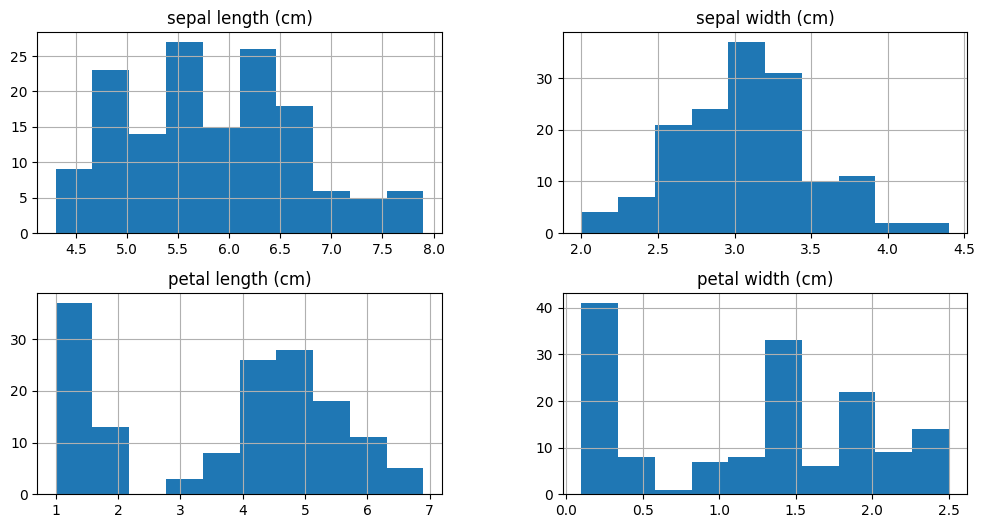

In [9]:
viz = X
viz.hist(figsize=(12,6))
plt.show()

In [10]:
# Display Statistical Analysis
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),149.0,5.843624,0.830851,4.3,5.1,5.8,6.4,7.9
sepal width (cm),149.0,3.059732,0.436342,2.0,2.8,3.0,3.3,4.4
petal length (cm),149.0,3.748993,1.767791,1.0,1.6,4.3,5.1,6.9
petal width (cm),149.0,1.194631,0.762622,0.1,0.3,1.3,1.8,2.5


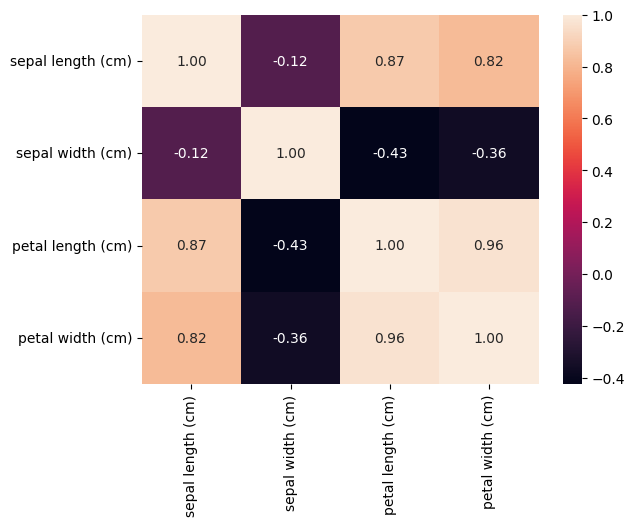

In [11]:
# Plot a correlation Heatmap for Correlation Analysis
X_corr = X.corr()
sns.heatmap(X_corr, annot = True, fmt = ".2f")
plt.show()

## Correlation Analysis
* This ia a Correlation Heatmap, which illustrate the linear relationship between all numerical features in the dataset and the variable.

## **Feature Scaling**
Scaling is critical for this dataset, because, k-Means is distance based

In [12]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.8980334 ,  1.01240113, -1.33325507, -1.30862368],
       [-1.13956224, -0.1373532 , -1.33325507, -1.30862368],
       [-1.38109108,  0.32254853, -1.39001364, -1.30862368],
       [-1.5018555 ,  0.09259766, -1.2764965 , -1.30862368],
       [-1.01879782,  1.242352  , -1.33325507, -1.30862368],
       [-0.53574014,  1.9322046 , -1.16297935, -1.04548613],
       [-1.5018555 ,  0.78245027, -1.33325507, -1.17705491],
       [-1.01879782,  0.78245027, -1.2764965 , -1.30862368],
       [-1.74338434, -0.36730407, -1.33325507, -1.30862368],
       [-1.13956224,  0.09259766, -1.2764965 , -1.44019246],
       [-0.53574014,  1.47230287, -1.2764965 , -1.30862368],
       [-1.26032666,  0.78245027, -1.21973792, -1.30862368],
       [-1.26032666, -0.1373532 , -1.33325507, -1.44019246],
       [-1.86414876, -0.1373532 , -1.50353079, -1.44019246],
       [-0.05268246,  2.16215547, -1.44677222, -1.30862368],
       [-0.17344688,  3.08195894, -1.2764965 , -1.04548613],
       [-0.53574014,  1.

# **Clustering Algorithm Implementation**

# 1. KMeans Clustering
KMeans is a method used to group data points based on similarity.

### How KMeans Clustering Works:

* Decide the number of clusters (k).
* Place k cluster centers randomly.
* Assign each data point to the nearest center.
* Update each center by taking the average of the points in that cluster.
* Repeat the process and update steps until clusters stop changing.


### Why KMeans clustering might be suitable for the Iris dataset:
* The dataset contains only **numerical values.**
* Flowers **can be grouped based on similar measurements.**
* The data naturally forms **three groups.**
* KMeans works well for small and well-separated datasets like Iris.

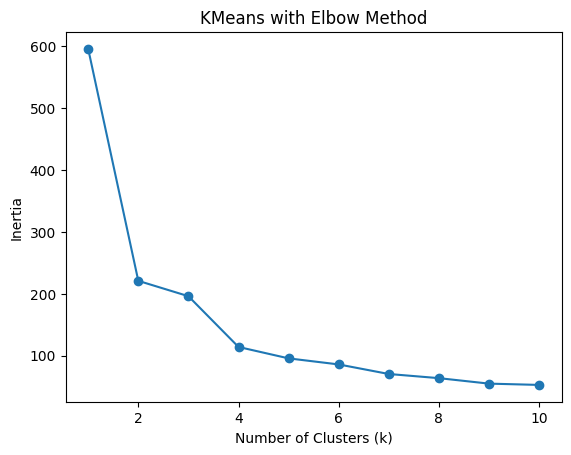

In [13]:
inertia = []
for k in range(1,11):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans with Elbow Method")
plt.show()

Elbow observed around **k = 3**

### Apply k-Means Clustering

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X["kmeans_cluster"] = clusters

/tmp/ipython-input-1234777760.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["kmeans_cluster"] = clusters


In [15]:
# Show Dataframe with "Cluster"
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),kmeans_cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


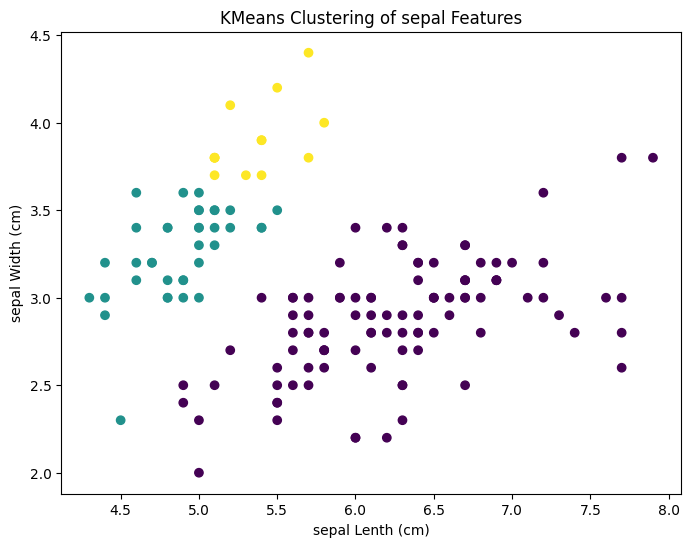

In [16]:
# Plot KMeans Cluster
plt.figure(figsize=(8,6))
plt.scatter(
    X["sepal length (cm)"],
    X["sepal width (cm)"],
    c=X["kmeans_cluster"],
)

plt.xlabel("sepal Lenth (cm)")
plt.ylabel("sepal Width (cm)")
plt.title("KMeans Clustering of sepal Features")
plt.show()

In [17]:
kmeans_summary = X.groupby('kmeans_cluster').mean()
kmeans_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
kmeans_cluster,,,,
0,6.266667,2.873737,4.904040,1.673737
1,4.878378,3.259459,1.440541,0.232432
2,5.369231,3.907692,1.523077,0.284615


1. **Cluster 0:**
* Represents large flowers
* Dominated by high petal length and width
* Largest and most spread cluster
* Absorbs most medium-to-large samples

2. **Cluster 1:**

* Represents small flowers
* Very small petal measurements
* Compact and clearly defined cluster
* Cleanly separated from others in feature space

3. **Cluster 2:**

* Also represents medium flowers with:
  * Wider sepals
  * Slightly larger petal dimensions than Cluster 1
* Acts as a sub-group within small flowers
* Indicates KMeans split the small-flower region into two clusters

In [18]:
X.groupby('kmeans_cluster').size()


,0
kmeans_cluster,
0,99
1,37
2,13


Hierarchical clustering successfully identified:

* A small-flower cluster
* A medium-flower cluster
* A large-flower cluster

# 2. Hierarchical Clustering

### How KMeans Clustering Works:
* Start by treating each data point as its own cluster.
* Find the two closest clusters based on distance.
* Merge these two clusters into one.
* Repeat this merging process step by step.
* Continue until all points form a single cluster.
* Use a dendrogram to decide where to cut and how many clusters to keep.


### Why KMeans clustering might be suitable for the Iris dataset:
* It **works well with small dataset**s like Iris.
* It **does not require fixing the number of clusters in advance.**
* The dendrogram clearly shows natural groupings in the data.
* Iris features are numerical, which fits distance-based clustering.
* Ward linkage helps form compact and meaningful clusters.


### Create a Dendrogram

In [ ]:
# Plot a Dendrogram for clustering
plt.figure(figsize=(14,6))
linkage = linkage(X_scaled, method="ward")
dendrogram(linkage)
plt.title("Dendrogram for Clustering")
plt.ylabel("Euclidean Distance")
plt.show()

From the Dendrogram, we choose: **3 clusters**

### Apply Hierarchical Clustering

In [ ]:
from sklearn import metrics
model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward"
)

hc_cluster = model.fit_predict(X_scaled)

In [ ]:
# Show Clustering
hc_cluster

In [ ]:
# Show Clustering in DataFrame
X["hc_cluster"] = hc_cluster
X

In [ ]:
# Plot Hierarchical Clustering of sepal Features
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X["sepal length (cm)"],
    y=X["sepal width (cm)"],
    hue=hc_cluster,
    palette="viridis"
)

plt.xlabel("sepal Length (cm)")
plt.ylabel("sepal Width (cm)")
plt.title("Hierarchical Clustering of sepal Features")
plt.show()

In [ ]:
hierarchical_summary = X.groupby('hc_cluster').mean()
hierarchical_summary


**Observations:**

1. Cluster 0:
* Represents large flowers
* Strong petal dimensions dominate this cluster
* This is the most spread-out and largest cluster

2. Cluster 1:
* Represents small flowers
* Extremely small petal measurements clearly separate this cluster
* Most compact and well-defined cluster

3. Cluster 2:
* Represents medium-sized flowers
* Acts as a transition cluster between small and large flowers
* Explains the overlap seen in the plot

In [ ]:
# Total count of Hierarchhical clusters
X.groupby('hc_cluster').size()

Hierarchical clustering successfully identified:

* A small-flower cluster
* A medium-flower cluster
* A large-flower cluster

# **CONCLUSION**
* In this project, clustering techniques were applied to the Iris dataset to identify natural groupings based on flower measurements.
* The species label was removed to ensure the analysis remained unsupervised.
* KMeans clustering successfully grouped the data into three clusters by minimizing the distance between data points and cluster centers.
* Hierarchical clustering also formed three meaningful clusters using distance-based merging, which was clearly visualized through a dendrogram.
* Cluster interpretation using group-wise averages showed that petal length and petal width were the most important features in separating the clusters.
* Sepal features contributed less to cluster separation due to overlap across samples.
* Both KMeans and Hierarchical clustering produced similar groupings, indicating strong underlying structure in the dataset.
* Overall, the results demonstrate that clustering algorithms can effectively discover patterns and similarities in real-world data without using predefined labels.


### **Best Algorithm: KMeans**
Why KMeans is the best here:
* The Iris dataset is small, clean, and numerical.
* The number of natural groups (3) is already known and clear.
* Clusters are compact and well separated, which matches KMeans assumptions.
* KMeans is fast, simple, and stable.
* Results are easy to interpret using cluster means.


### **Worst: Hierarchical clustering**

Reason: Higher complexity with no significant improvement in results.